In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


--- Data Overview ---
CRM Opportunities Volume: 1200 deals in progress.
ERP Goods Receipts Volume: 760 logistics movements.

First 3 rows of CRM Opportunities:


,OpportunityId,AccountId,AccountName,OpportunityName,Product,Quantity,Amount_EUR,Stage,Probability,CloseDate,CreatedDate,SalesRep,LeadSource,CycleLength_Days,Anomaly,Region
0,OPP00001,ACC0001,Indian Air Force,Upgrade EW Suite — India (1 units),Upgrade EW Suite,1,7.788098e+06,Negotiation,75,2027-07-15,2020-02-16,Antoine Morel,Diplomatic Channel,NaN,NaN,Asia
1,OPP00002,ACC0001,Indian Air Force,Upgrade EW Suite — India (1 units),Upgrade EW Suite,1,7.242006e+06,Prospecting,10,2027-02-05,2020-01-01,Marc Dupont,Referral,NaN,NaN,Asia
2,OPP00003,ACC0001,Indian Air Force,Rafale F3-R — India (12 units),Rafale F3-R,12,1.159890e+09,Closed Won,100,2024-03-26,2023-05-09,Jean-Pierre Martin,Air Show,322.0,NaN,Asia



--- SALESFORCE PIPELINE AUDIT ---
Pipeline by Stage (in Billions €):
 Stage
Closed Lost      29.68
Closed Won       63.08
Negotiation      57.72
Proposal         75.37
Prospecting      36.69
Qualification    44.72
Name: Amount_EUR, dtype: float64

ALERT: 19 deals show a CRM inconsistency!

Sample of CRM anomalies:


,OpportunityId,Stage,Amount_EUR,Anomaly
9,OPP00010,Closed Won,0.00,AMOUNT_ZERO_ON_CLOSED_WON
11,OPP00012,Closed Won,0.00,AMOUNT_ZERO_ON_CLOSED_WON
15,OPP00016,Closed Won,0.00,AMOUNT_ZERO_ON_CLOSED_WON
35,OPP00036,Negotiation,15108161.35,STALE_NEGOTIATION
36,OPP00037,Closed Won,0.00,AMOUNT_ZERO_ON_CLOSED_WON



--- SUPPLIER DELAYS (MIGO) AUDIT ---
Number of delayed receipts: 428 out of 760 total.

Average delay (in days) per production site:
Plant
Bangalore    18.4
Bordeaux     24.9
Hyderabad    30.1
Merignac     21.8
Nagpur       21.8
Name: Delay_Days, dtype: float64


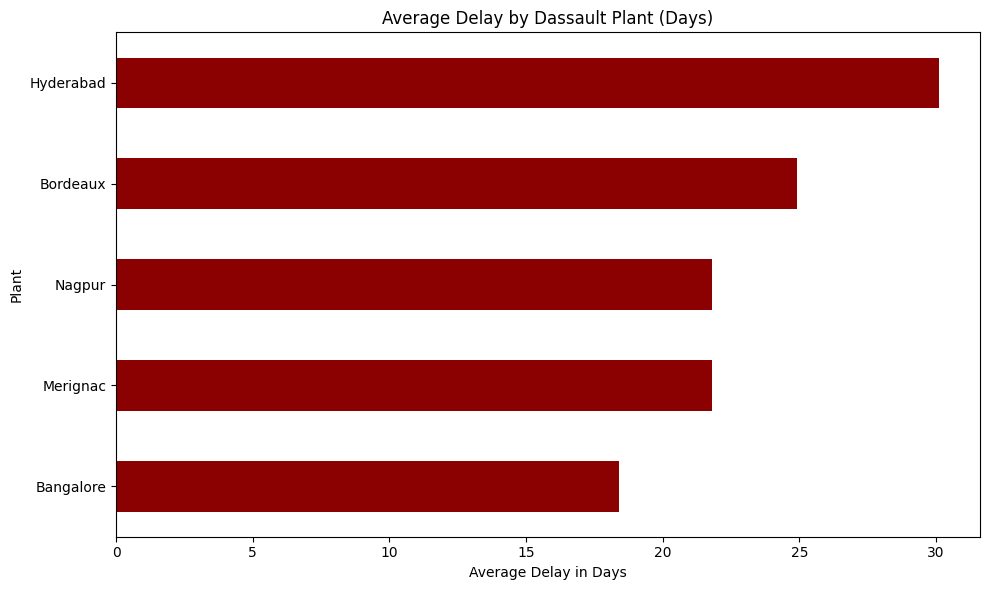

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Configuration ---
# Assuming files are in 'Colab Notebooks' folder within MyDrive
CRM_FILE_PATH = '/content/CRM_Opportunities.csv'
MIGO_FILE_PATH = '/content/ERP_GoodsReceipts_MIGO.csv'
BILLION = 1e9 # Constant for converting to billions

# --- Data Loading ---
# Load the two key datasets
df_opportunities = pd.read_csv(CRM_FILE_PATH)
df_goods_receipts = pd.read_csv(MIGO_FILE_PATH)

# Basic display to confirm data loading
print("--- Data Overview ---")
print(f"CRM Opportunities Volume: {df_opportunities.shape[0]} deals in progress.")
print(f"ERP Goods Receipts Volume: {df_goods_receipts.shape[0]} logistics movements.")

# Display the first 3 rows of the CRM data
print("\nFirst 3 rows of CRM Opportunities:")
display(df_opportunities.head(3))

# --- Salesforce Pipeline Audit ---
print("\n--- SALESFORCE PIPELINE AUDIT ---")

# Calculate total revenue in the pipeline by stage (Amount_EUR in billions)
pipeline_summary = df_opportunities.groupby('Stage')['Amount_EUR'].sum() / BILLION
print("Pipeline by Stage (in Billions €):\n", pipeline_summary.round(2))

# Track business anomalies
crm_anomalies = df_opportunities[df_opportunities['Anomaly'].notnull()]
print(f"\nALERT: {len(crm_anomalies)} deals show a CRM inconsistency!")

# Display a sample of these anomalies
print("\nSample of CRM anomalies:")
display(crm_anomalies[['OpportunityId', 'Stage', 'Amount_EUR', 'Anomaly']].head())

# --- Supplier Delays (MIGO) Audit ---
print("\n--- SUPPLIER DELAYS (MIGO) AUDIT ---")

# Filter only for delayed deliveries
late_receipts = df_goods_receipts[df_goods_receipts['IsLate'] == True]
print(f"Number of delayed receipts: {len(late_receipts)} out of {len(df_goods_receipts)} total.")

# Calculate the average delay time per plant
avg_delay_by_plant = late_receipts.groupby('Plant')['Delay_Days'].mean().round(1)
print("\nAverage delay (in days) per production site:")
print(avg_delay_by_plant)

# Display a simple chart to illustrate
plt.figure(figsize=(10, 6)) # Add figure size for better readability
avg_delay_by_plant.sort_values().plot(kind='barh', color='darkred', title="Average Delay by Dassault Plant (Days)")
plt.xlabel("Average Delay in Days") # Add x-axis label
plt.ylabel("Plant") # Add y-axis label
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

In [4]:
print('Colab Notebooks')

Colab Notebooks
